In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['pdf.fonttype'] = 42
plt.rc('text', usetex=True)
plt.rcParams['font.sans-serif'] = "Arial"

df_all = pd.read_csv("AIDE_baseline_dermatologists_aggregated.csv")

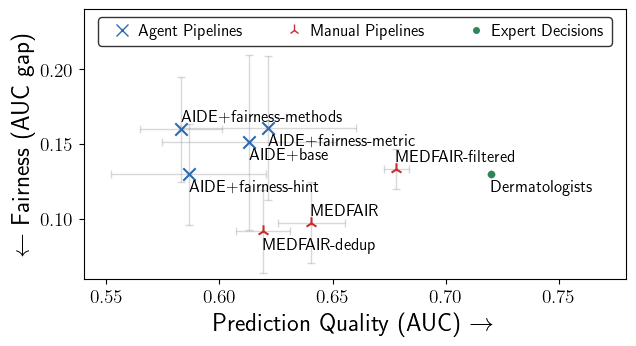

In [8]:
labels = {
    'basic_prompt': 'AIDE+base',
    'addition_1': 'AIDE+fairness-hint',
    'addition_2': 'AIDE+fairness-metric',
    'addition_3': 'AIDE+fairness-methods',
    'Fitzpatrick_17kC': 'MEDFAIR-dedup',
    'Fitzpatrick17kC_binary': 'MEDFAIR-filtered',
    'Full_fitz17k': 'MEDFAIR',
    'dermatologists': 'Dermatologists'
}    

offsets = {
    'basic_prompt': -0.017,
    'addition_1': -0.017,
    'addition_2': -0.017,
    'addition_3': 0,
    'Fitzpatrick_17kC': -0.017,
    'Fitzpatrick17kC_binary': 0,
    'Full_fitz17k': 0,
    'dermatologists': -0.017,
}   

markers = {
    'basic_prompt': 'x',
    'addition_1': 'x',
    'addition_2': 'x',
    'addition_3': 'x',
    'Fitzpatrick_17kC': '2',
    'Fitzpatrick17kC_binary': '2',
    'Full_fitz17k': '2',
    'dermatologists': '.',
}   

blue = '#2B6CB0'
red = '#C53030'
green = '#2F855A'

colors = [blue, blue, blue, blue, red, red, red, green]

df = df_all[df_all.statistic=='mean']
df_std = df_all[df_all.statistic=='std']

plt.errorbar(
    df['Test Overall AUC'],
    df['Test auc_gap'],
    xerr=df_std['Test Overall AUC'],
    yerr=df_std['Test auc_gap'],
    fmt='o',
    color='grey',
    capsize=3,
    elinewidth=1,
    markersize=0,
    zorder=1,
    alpha=0.3
)

#plt.scatter(df['Test Overall AUC'], df['AUC_Difference'], color=colors, marker='x')
for i, row in df.iterrows():
    plt.scatter(
        row['Test Overall AUC'],
        row['Test auc_gap'],
        marker=markers[row['prompt']],
        color=colors[df.index.get_loc(i)],
        s=80,
    )


for _, row in df.iterrows():
    plt.annotate(labels[row['prompt']], (row['Test Overall AUC'], row['Test auc_gap'] + 0.005 + offsets[row['prompt']]), fontsize=12)

label_size = 18
tick_size = 14
legend_size = 16

plt.xlabel('Prediction Quality (AUC) $\\rightarrow$', fontsize=label_size)
plt.ylabel('$\leftarrow$ Fairness (AUC gap)', fontsize=label_size)
plt.ylim((0.06, 0.24))
plt.xlim((0.54, 0.78))

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='x', color=blue, markersize=8, linestyle='None', label='Agent Pipelines'),
    Line2D([0], [0], marker='2', color=red, markersize=8, linestyle='None', label='Manual Pipelines'),
    Line2D([0], [0], marker='.', color=green, markersize=8, linestyle='None', label='Expert Decisions'),
]

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=tick_size)
ax.tick_params(axis='both', which='minor', labelsize=tick_size)

plt.legend(handles=legend_elements, ncol=3, fontsize=12, handletextpad=0.0,loc='upper center', edgecolor='black')
plt.gcf().set_size_inches(7, 3.5)
plt.savefig('../figures/quality-vs-fairness.pdf', dpi=300, bbox_inches='tight')
plt.show()


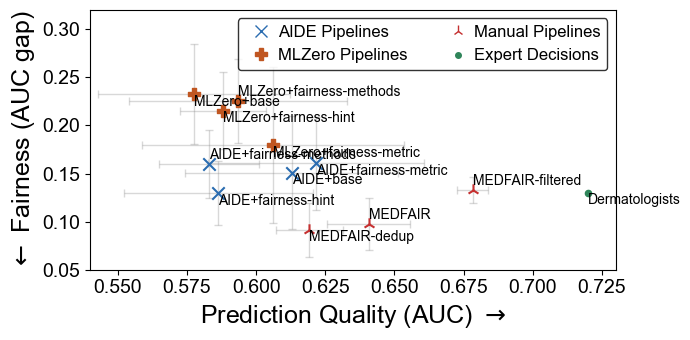

In [31]:
# claude code updated:

import matplotlib
matplotlib.rcParams['text.usetex'] = False

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.rcParams['pdf.fonttype'] = 42
plt.rc('text', usetex=False)
plt.rcParams['font.sans-serif'] = "Arial"

df_all = pd.read_csv("AIDE_MLZero_Baseline_Human_aggregated.csv")

labels = {
    'basic_prompt':          'AIDE+base',
    'addition_1':            'AIDE+fairness-hint',
    'addition_2':            'AIDE+fairness-metric',
    'addition_3':            'AIDE+fairness-methods',
    'mlzero_bp':             'MLZero+base',
    'mlzero_add1':           'MLZero+fairness-hint',
    'mlzero_add2':           'MLZero+fairness-metric',
    'mlzero_add3':           'MLZero+fairness-methods',
    'Fitzpatrick_17kC':      'MEDFAIR-dedup',
    'Fitzpatrick17kC_binary':'MEDFAIR-filtered',
    'Full_fitz17k':          'MEDFAIR',
    'dermatologists':        'Dermatologists',
}

offsets = {
    'basic_prompt':          -0.017,
    'addition_1':            -0.017,
    'addition_2':            -0.017,
    'addition_3':             0,
    'mlzero_bp':             -0.017,
    'mlzero_add1':           -0.017,
    'mlzero_add2':           -0.017,
    'mlzero_add3':            0,
    'Fitzpatrick_17kC':      -0.017,
    'Fitzpatrick17kC_binary': 0,
    'Full_fitz17k':           0,
    'dermatologists':        -0.017,
}

markers = {
    'basic_prompt':          'x',
    'addition_1':            'x',
    'addition_2':            'x',
    'addition_3':            'x',
    'mlzero_bp':             'P',
    'mlzero_add1':           'P',
    'mlzero_add2':           'P',
    'mlzero_add3':           'P',
    'Fitzpatrick_17kC':      '2',
    'Fitzpatrick17kC_binary':'2',
    'Full_fitz17k':          '2',
    'dermatologists':        '.',
}

blue   = '#2B6CB0'
orange = '#C05621'
red    = '#C53030'
green  = '#2F855A'

model_colors = {
    'AIDE':     blue,
    'MLZero':   orange,
    'Baseline': red,
    'human':    green,
}

df_mean = df_all[df_all.statistic == 'mean'].copy().reset_index(drop=True)
df_std  = df_all[df_all.statistic == 'std'].set_index('prompt')

# Attach std values where available (human/dermatologists row has no std)
df_mean['xerr'] = df_mean['prompt'].map(df_std['Test Overall AUC'])
df_mean['yerr'] = df_mean['prompt'].map(df_std['Test auc_gap'])

fig, ax = plt.subplots(figsize=(7, 3.5))

# Error bars (only for rows that have std data)
for _, row in df_mean.iterrows():
    if pd.notna(row['xerr']) and pd.notna(row['yerr']):
        ax.errorbar(
            row['Test Overall AUC'], row['Test auc_gap'],
            xerr=row['xerr'], yerr=row['yerr'],
            fmt='o', color='grey', capsize=3,
            elinewidth=1, markersize=0, zorder=1, alpha=0.3,
        )

# Scatter points
for _, row in df_mean.iterrows():
    color = model_colors.get(row['model'], 'black')
    ax.scatter(
        row['Test Overall AUC'], row['Test auc_gap'],
        marker=markers[row['prompt']], color=color, s=80, zorder=2,
    )

# Annotations
for _, row in df_mean.iterrows():
    ax.annotate(
        labels[row['prompt']],
        (row['Test Overall AUC'], row['Test auc_gap'] + 0.005 + offsets[row['prompt']]),
        fontsize=10,
    )

label_size = 18
tick_size  = 14

ax.set_xlabel('Prediction Quality (AUC) $\\rightarrow$', fontsize=label_size)
ax.set_ylabel('$\\leftarrow$ Fairness (AUC gap)', fontsize=label_size)
ax.set_ylim((0.05, 0.32))
ax.set_xlim((0.54, 0.73))

legend_elements = [
    Line2D([0], [0], marker='x', color=blue,   markersize=8, linestyle='None', label='AIDE Pipelines'),
    Line2D([0], [0], marker='P', color=orange,  markersize=8, linestyle='None', label='MLZero Pipelines'),
    Line2D([0], [0], marker='2', color=red,    markersize=8, linestyle='None', label='Manual Pipelines'),
    Line2D([0], [0], marker='.', color=green,  markersize=8, linestyle='None', label='Expert Decisions'),
]

ax.tick_params(axis='both', which='major', labelsize=tick_size)
ax.tick_params(axis='both', which='minor', labelsize=tick_size)

plt.legend(handles=legend_elements, ncol=2, fontsize=12,
           handletextpad=0.0, loc='upper right', edgecolor='black')
plt.tight_layout()
#plt.savefig('../figures/quality-vs-fairness-full.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/Users/arichter/Documents/GitHub/be-fair/evaluation/MEDFAIR_evaluations/quality-vs-fairness-full.pdf', dpi=300, bbox_inches='tight')
plt.show()